# RQ6 — Spatial Overlay Analysis: Housing Equity × Population Vulnerability

**Research Question:** When housing typology and population vulnerability are jointly
considered, which spatial units face compounded disadvantage, and what targeted policy
interventions do they require?

**Analytical Framework:**

| Layer | Source | Variable |
|---|---|---|
| Housing typology (NB04) | K-Means on 5 HEI dimensions | `cluster_type` (A = best → E = worst equity) |
| Population typology (NB05) | K-Means on Census 2021 demographics | `pop_label` (Deprived / Elderly / Family / Professional) |

**Pipeline:**
1. Data merge & typology overview
2. Cross-tabulation matrix + independence test (χ², Cramér's V)
3. Joint typology construction (housing × population combined label)
4. Spatial overlay maps (side-by-side + joint priority map)
5. Vulnerability surface: housing deprivation score × population vulnerability score
6. Bivariate Moran's I — spatial co-clustering of key indicator pairs
7. Policy intervention matrix by joint typology
8. Composite priority scoring & top-priority LSOA identification

---
## 1. Setup & Data Loading

In [39]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings, os
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})

BASE    = os.path.dirname(os.path.abspath('__file__'))
DATA    = os.path.join(BASE, 'data')
SHP_DIR = os.path.join(BASE, 'LSOA_Shapfile')
FIG_DIR = os.path.join(BASE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


In [40]:
# ── Load housing typology (NB04 output) ───────────────────────────────────
housing = pd.read_csv(os.path.join(DATA, 'southwark_clusters.csv'))
HEI_FEAT_COLS = ['avg_epc_rating_num_al', 'overcrowding_proxy_al',
                 'median_house_price_al', 'transport_ptai_al', 'hospital_al']
housing = housing[['lsoa21cd', 'lsoa21nm', 'cluster_type', 'HEI_bayes'] + HEI_FEAT_COLS]            .drop_duplicates('lsoa21cd').reset_index(drop=True)

# ── Load population typology (NB05 output) ────────────────────────────────
POP_VARS = ['pct_poor_health', 'pct_low_nssec', 'pct_elderly_alone',
            'pct_dep_children', 'pct_deprived_2plus', 'pct_long_commute', 'pct_large_hh']
population = pd.read_csv(os.path.join(DATA, 'southwark_rq5_population_sensitivity.csv'))
population = population[['lsoa21cd', 'pop_label', 'HEI_quintile',
                         'HEI_adjusted', 'zone_type'] + POP_VARS]               .drop_duplicates('lsoa21cd').reset_index(drop=True)

# ── Merge ─────────────────────────────────────────────────────────────────
df = housing.merge(population, on='lsoa21cd', how='inner')

HT_ORDER = sorted(df['cluster_type'].dropna().unique())   # e.g. A,B,C,D,E
PT_ORDER = [l for l in ['Deprived','Elderly','Family','Professional']
            if l in df['pop_label'].values]

print(f'Overlay dataset: {len(df)} LSOAs × {df.shape[1]} variables')
print(f'Housing types : {HT_ORDER}')
print(f'Population types: {PT_ORDER}')
df.head(3)

Overlay dataset: 173 LSOAs × 20 variables
Housing types : ['A', 'B', 'C', 'D']
Population types: ['Deprived', 'Family', 'Professional']


,lsoa21cd,lsoa21nm,cluster_type,HEI_bayes,avg_epc_rating_num_al,overcrowding_proxy_al,median_house_price_al,transport_ptai_al,hospital_al,pop_label,HEI_quintile,HEI_adjusted,zone_type,pct_poor_health,pct_low_nssec,pct_elderly_alone,pct_dep_children,pct_deprived_2plus,pct_long_commute,pct_large_hh
0,E01003911,Southwark 020A,C,0.724,0.501,0.642,0.105,0.897,0.813,Deprived,Q5 (worst),0.328,Double Deprivation,0.038,0.303,0.054,0.331,0.225,0.024,0.121
1,E01003912,Southwark 019A,C,0.789,0.659,0.717,0.164,0.905,0.749,Deprived,Q5 (worst),0.332,Double Deprivation,0.042,0.398,0.047,0.444,0.275,0.033,0.126
2,E01003913,Southwark 024A,D,0.676,0.592,0.354,0.302,0.784,0.867,Family,Q4,0.259,Housing Deprived,0.022,0.207,0.072,0.256,0.114,0.019,0.068


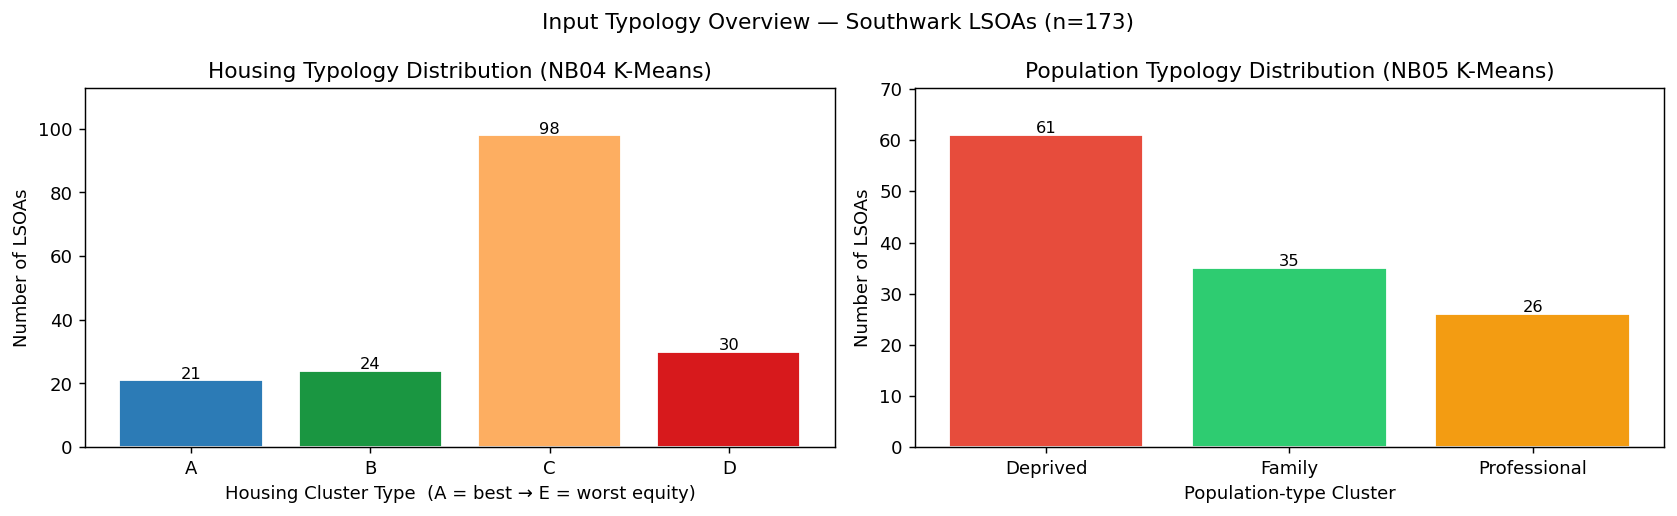

In [41]:
# ── Colour maps ──────────────────────────────────────────────────────────
HT_COLORS = {'A':'#2c7bb6','B':'#1a9641','C':'#fdae61','D':'#d7191c','E':'#9b59b6'}
PT_COLORS  = {'Deprived':'#e74c3c','Elderly':'#3498db',
               'Family':'#2ecc71','Professional':'#f39c12'}

# ── Typology overview: dual bar chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ht_vc = df['cluster_type'].value_counts().reindex(HT_ORDER)
axes[0].bar(ht_vc.index, ht_vc.values,
            color=[HT_COLORS.get(t,'#aaa') for t in ht_vc.index], edgecolor='white')
for i,(t,n) in enumerate(ht_vc.items()):
    axes[0].text(i, n+0.5, str(n), ha='center', fontsize=9)
axes[0].set(title='Housing Typology Distribution (NB04 K-Means)',
            xlabel='Housing Cluster Type  (A = best → E = worst equity)',
            ylabel='Number of LSOAs')
axes[0].set_ylim(0, ht_vc.max()*1.15)

pt_vc = df['pop_label'].value_counts().reindex(PT_ORDER)
axes[1].bar(pt_vc.index, pt_vc.values,
            color=[PT_COLORS.get(t,'#aaa') for t in pt_vc.index], edgecolor='white')
for i,(t,n) in enumerate(pt_vc.items()):
    axes[1].text(i, n+0.5, str(n), ha='center', fontsize=9)
axes[1].set(title='Population Typology Distribution (NB05 K-Means)',
            xlabel='Population-type Cluster',
            ylabel='Number of LSOAs')
axes[1].set_ylim(0, pt_vc.max()*1.15)

plt.suptitle('Input Typology Overview — Southwark LSOAs (n=173)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_typology_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Cross-tabulation Analysis

In [42]:
# ── 2.1  Cross-tabulation: Housing Type × Population Type ────────────────
ct = pd.crosstab(df['cluster_type'], df['pop_label'])
ct = ct.reindex(index=HT_ORDER, columns=PT_ORDER, fill_value=0)

# Row percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print('=== Count cross-tabulation ===')
print(ct)
print()
print('=== Row percentages ===')
print(ct_pct.round(1))

=== Count cross-tabulation ===
pop_label     Deprived  Family  Professional
cluster_type                                
A                    5      10             3
B                    2       0            11
C                   54       3             9
D                    0      22             3

=== Row percentages ===
pop_label     Deprived  Family  Professional
cluster_type                                
A               27.800  55.600        16.700
B               15.400   0.000        84.600
C               81.800   4.500        13.600
D                0.000  88.000        12.000


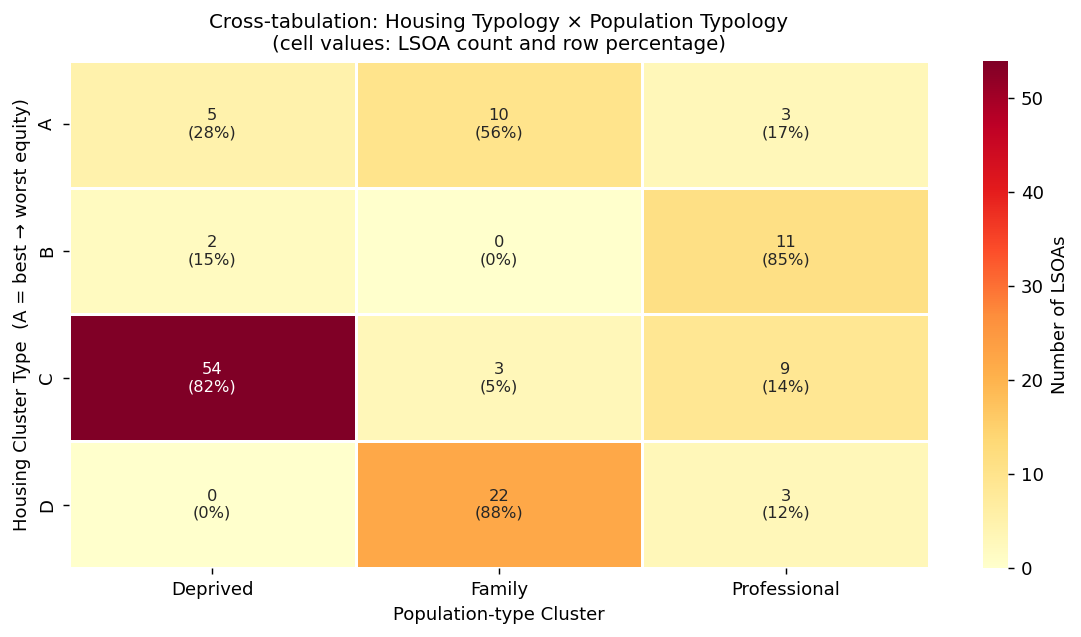

In [43]:
# ── 2.2  Heatmap: counts + row % ─────────────────────────────────────────
# Build annotation strings: "count\n(row%)"
annot = ct.copy().astype(object)
for r in ct.index:
    for c in ct.columns:
        annot.loc[r, c] = f"{ct.loc[r,c]}\n({ct_pct.loc[r,c]:.0f}%)"

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=annot, fmt='', cmap='YlOrRd', ax=ax,
            linewidths=0.6, annot_kws={'fontsize': 9},
            cbar_kws={'label': 'Number of LSOAs'})
ax.set_title('Cross-tabulation: Housing Typology × Population Typology\n'
             '(cell values: LSOA count and row percentage)', fontsize=11)
ax.set_xlabel('Population-type Cluster')
ax.set_ylabel('Housing Cluster Type  (A = best → worst equity)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_crosstab_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# ── 2.3  Chi-square independence test + Cramér's V ───────────────────────
chi2, p, dof, expected = chi2_contingency(ct.values)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

sig_label = '*** (p < 0.001)' if p < 0.001 else ('** (p < 0.01)' if p < 0.01 else
             ('* (p < 0.05)' if p < 0.05 else 'ns (p ≥ 0.05)'))
effect     = 'large' if cramers_v >= 0.5 else ('medium' if cramers_v >= 0.3 else 'small')

print('=== Independence Test: Housing Typology × Population Typology ===')
print(f'χ²         = {chi2:.3f}')
print(f'df         = {dof}')
print(f'p-value    = {p:.4f}  {sig_label}')
print(f"Cramér's V = {cramers_v:.3f}  ({effect} effect size)")
print()
if p < 0.05:
    print('→ Housing type and population type are NOT spatially independent.')
    print('  Certain population groups are systematically concentrated in')
    print('  specific housing equity zones.')
else:
    print('→ No statistically significant association detected.')

=== Independence Test: Housing Typology × Population Typology ===
χ²         = 110.549
df         = 6
p-value    = 0.0000  *** (p < 0.001)
Cramér's V = 0.673  (large effect size)

→ Housing type and population type are NOT spatially independent.
  Certain population groups are systematically concentrated in
  specific housing equity zones.


---
## 3. Joint Typology Construction

In [45]:
# ── 3.1  Assign ordinal deprivation scores ────────────────────────────────
# Housing score: A=1 (best) → E=5 (worst)
ht_score_map = {t: i+1 for i, t in enumerate(HT_ORDER)}

# Population vulnerability score based on mean composite of key indicators
pop_vuln_raw = (df.groupby('pop_label')[POP_VARS].mean()
                  .mean(axis=1).rank().astype(int))
pop_score_map = pop_vuln_raw.to_dict()

df['housing_score'] = df['cluster_type'].map(ht_score_map)
df['pop_score']     = df['pop_label'].map(pop_score_map)
df['joint_score']   = df['housing_score'] + df['pop_score']

# ── 3.2  5-category joint classification ─────────────────────────────────
max_score = df['housing_score'].max() + df['pop_score'].max()

def classify_joint(row):
    h = row['housing_score']
    p = row['pop_score']
    s = h + p
    n_ht = len(HT_ORDER)
    n_pt = len(PT_ORDER)
    # Thresholds scaled to actual range
    q20 = 2 + 1                  # best possible + 1 step
    q80 = n_ht + n_pt - 1        # 1 step below worst
    if h <= 2 and p == 1:
        return 'Double Advantage'
    elif h >= (n_ht - 1) and p == n_pt:
        return 'Double Disadvantage'
    elif h >= (n_ht - 1):
        return 'Housing Disadvantage'
    elif p == n_pt:
        return 'Population Disadvantage'
    else:
        return 'Transitional'

df['joint_type'] = df.apply(classify_joint, axis=1)

JOINT_ORDER  = ['Double Disadvantage','Housing Disadvantage',
                'Population Disadvantage','Transitional','Double Advantage']
JOINT_COLORS = {'Double Disadvantage' : '#c0392b',
                'Housing Disadvantage' : '#e67e22',
                'Population Disadvantage': '#8e44ad',
                'Transitional'         : '#95a5a6',
                'Double Advantage'     : '#1a5276'}

print('Joint typology distribution:')
print(df['joint_type'].value_counts().reindex(JOINT_ORDER).dropna())
print()
print('Mean HEI_bayes by joint type:')
print(df.groupby('joint_type')['HEI_bayes'].mean().reindex(JOINT_ORDER).dropna().round(3))

Joint typology distribution:
joint_type
Double Disadvantage        37
Housing Disadvantage       91
Population Disadvantage    14
Transitional               17
Double Advantage           14
Name: count, dtype: int64

Mean HEI_bayes by joint type:
joint_type
Double Disadvantage       0.600
Housing Disadvantage      0.601
Population Disadvantage   0.524
Transitional              0.255
Double Advantage          0.497
Name: HEI_bayes, dtype: float64


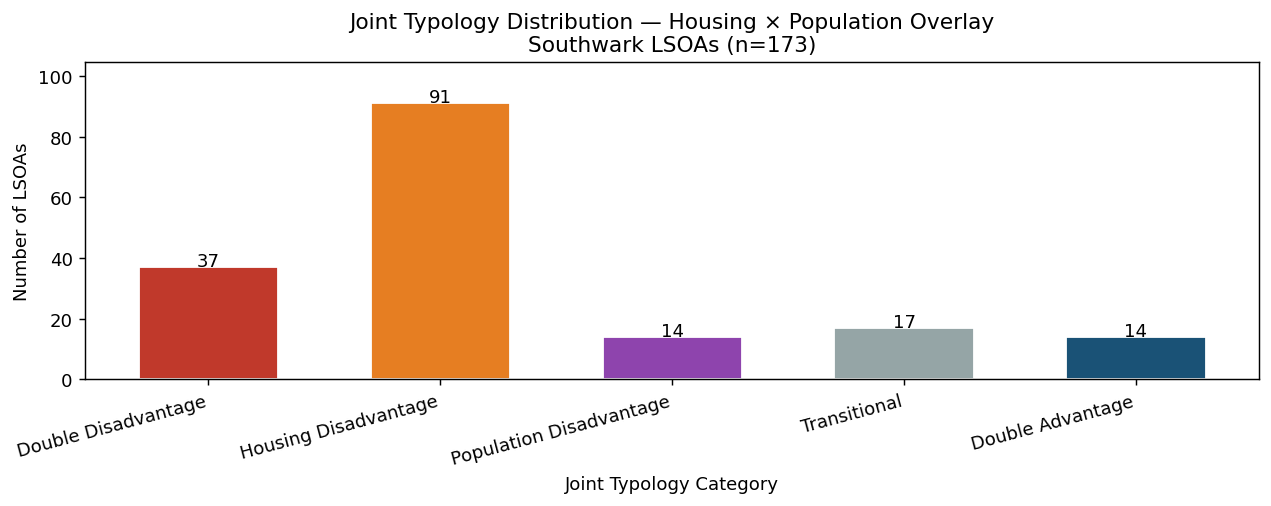

In [46]:
# ── 3.3  Joint type distribution bar chart ───────────────────────────────
jt_vc = df['joint_type'].value_counts().reindex(JOINT_ORDER).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(jt_vc.index, jt_vc.values,
              color=[JOINT_COLORS[t] for t in jt_vc.index], edgecolor='white', width=0.6)
for bar, n in zip(bars, jt_vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.4,
            str(int(n)), ha='center', fontsize=10)
ax.set(title='Joint Typology Distribution — Housing × Population Overlay\n'
             'Southwark LSOAs (n=173)',
       xlabel='Joint Typology Category', ylabel='Number of LSOAs')
ax.set_xticklabels(jt_vc.index, rotation=15, ha='right')
ax.set_ylim(0, jt_vc.max()*1.15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_joint_type_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Spatial Overlay Maps

In [47]:
# ── Load shapefile ───────────────────────────────────────────────────────
gdf = gpd.read_file(os.path.join(SHP_DIR, 'Southwark.shp')).to_crs(epsg=27700)
geo_col = 'lsoa21cd' if 'lsoa21cd' in gdf.columns else gdf.columns[0]

geo = gdf.merge(df[['lsoa21cd','cluster_type','pop_label','joint_type',
                     'housing_score','pop_score','joint_score','HEI_bayes']]                  .drop_duplicates('lsoa21cd'),
                left_on=geo_col, right_on='lsoa21cd', how='left')
print(f'GeoDataFrame: {geo.shape}')
print('Missing joint_type:', geo['joint_type'].isna().sum())

GeoDataFrame: (173, 14)
Missing joint_type: 0


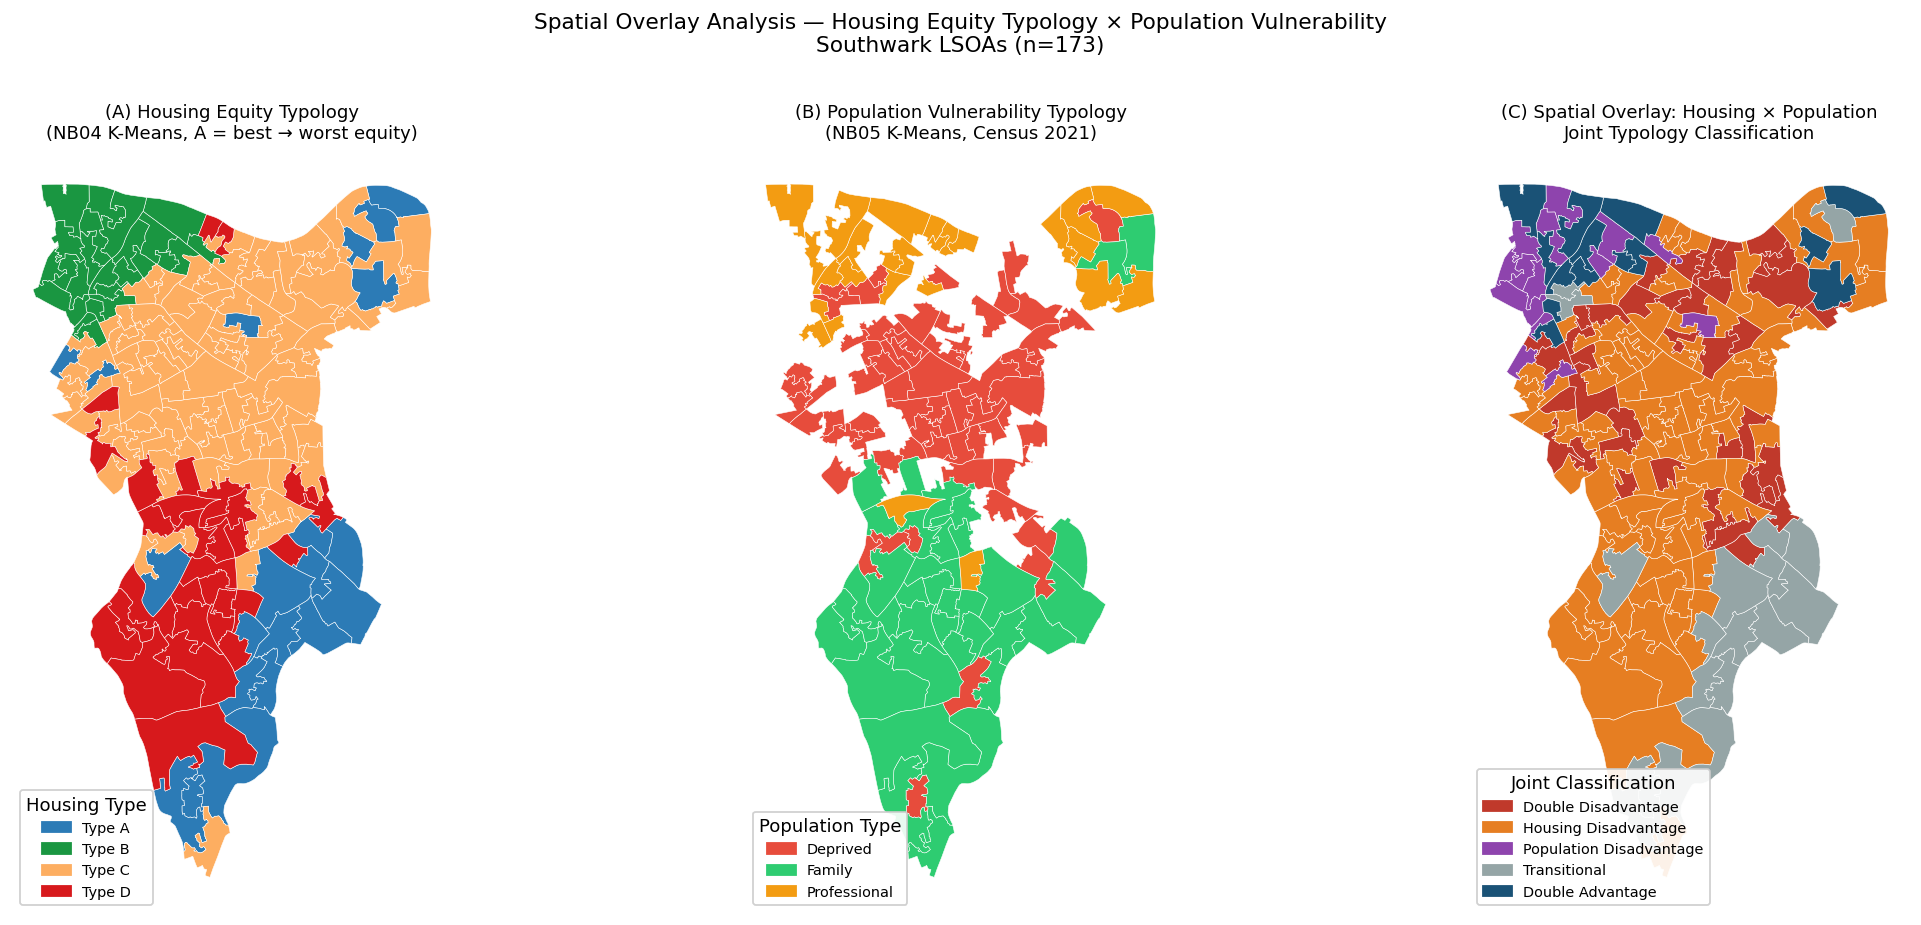

In [48]:
# ── 4.1  Three-panel map: Housing | Population | Joint ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Panel A: Housing typology
for t in HT_ORDER:
    sub = geo[geo['cluster_type'] == t]
    if not sub.empty:
        sub.plot(ax=axes[0], color=HT_COLORS.get(t,'#aaa'), edgecolor='white', linewidth=0.3)
geo[geo['cluster_type'].isna()].plot(ax=axes[0], color='lightgrey', edgecolor='white', linewidth=0.3)
ht_handles = [mpatches.Patch(color=HT_COLORS.get(t,'#aaa'), label=f'Type {t}') for t in HT_ORDER]
axes[0].legend(handles=ht_handles, title='Housing Type', fontsize=8, loc='lower left', framealpha=0.9)
axes[0].set_title('(A) Housing Equity Typology\n(NB04 K-Means, A = best → worst equity)', fontsize=10)
axes[0].axis('off')

# Panel B: Population typology
for t in PT_ORDER:
    sub = geo[geo['pop_label'] == t]
    if not sub.empty:
        sub.plot(ax=axes[1], color=PT_COLORS.get(t,'#aaa'), edgecolor='white', linewidth=0.3)
geo[geo['pop_label'].isna()].plot(ax=axes[1], color='lightgrey', edgecolor='white', linewidth=0.3)
pt_handles = [mpatches.Patch(color=PT_COLORS.get(t,'#aaa'), label=t) for t in PT_ORDER]
axes[1].legend(handles=pt_handles, title='Population Type', fontsize=8, loc='lower left', framealpha=0.9)
axes[1].set_title('(B) Population Vulnerability Typology\n(NB05 K-Means, Census 2021)', fontsize=10)
axes[1].axis('off')

# Panel C: Joint typology
for jt in JOINT_ORDER:
    sub = geo[geo['joint_type'] == jt]
    if not sub.empty:
        sub.plot(ax=axes[2], color=JOINT_COLORS[jt], edgecolor='white', linewidth=0.3)
geo[geo['joint_type'].isna()].plot(ax=axes[2], color='lightgrey', edgecolor='white', linewidth=0.3)
jt_handles = [mpatches.Patch(color=JOINT_COLORS[jt], label=jt) for jt in JOINT_ORDER]
axes[2].legend(handles=jt_handles, title='Joint Classification', fontsize=8, loc='lower left', framealpha=0.9)
axes[2].set_title('(C) Spatial Overlay: Housing × Population\nJoint Typology Classification', fontsize=10)
axes[2].axis('off')

plt.suptitle('Spatial Overlay Analysis — Housing Equity Typology × Population Vulnerability\n'
             'Southwark LSOAs (n=173)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_triple_map.png'), dpi=150, bbox_inches='tight')
plt.show()

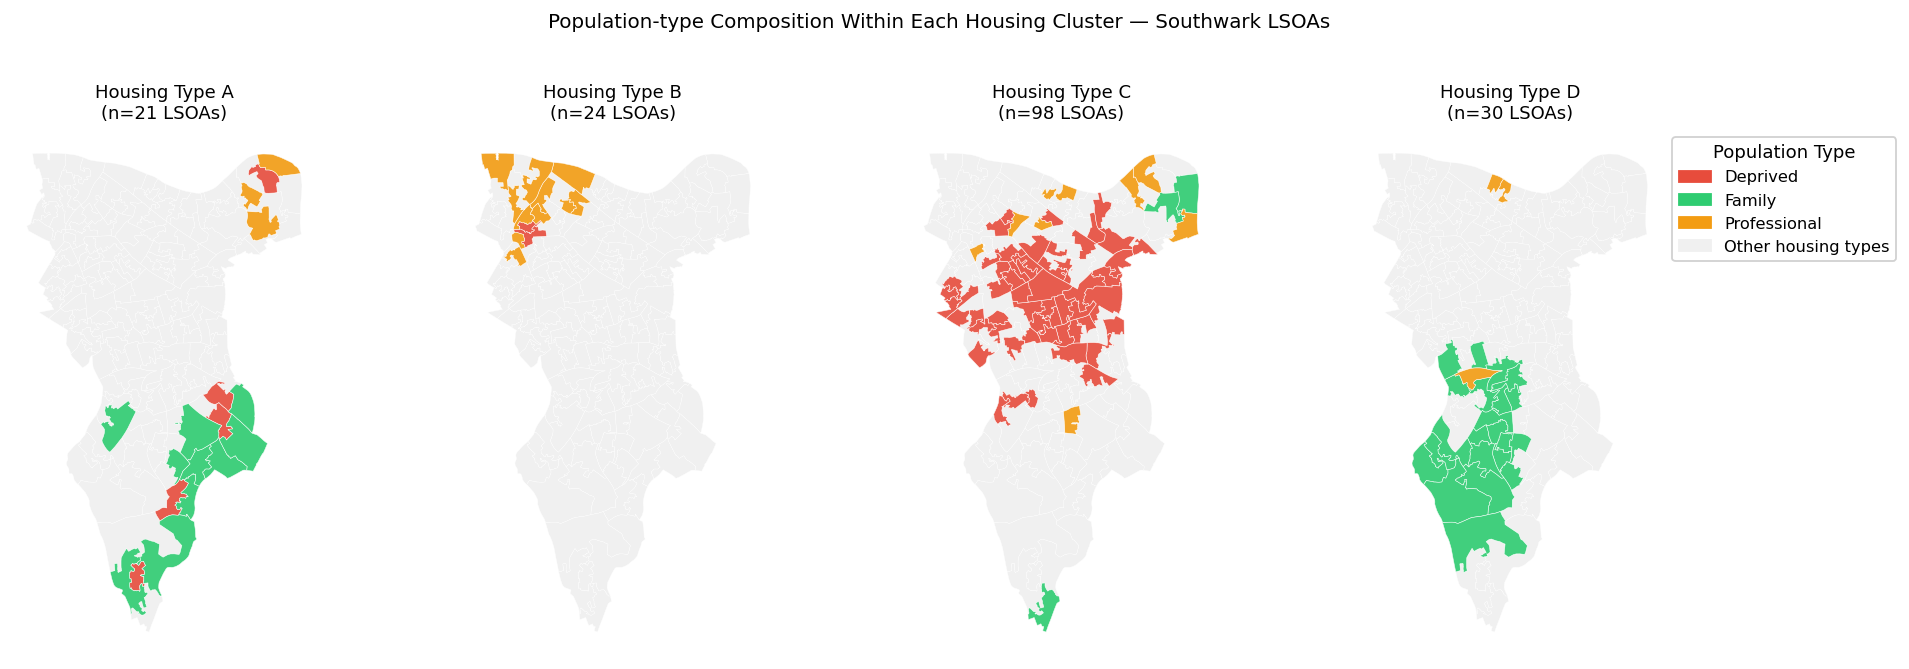

In [49]:
# ── 4.2  Housing-Population combination grid (small multiples) ───────────
# One subplot per housing type, shaded by population type
n_ht = len(HT_ORDER)
fig, axes = plt.subplots(1, n_ht, figsize=(4*n_ht, 5))
if n_ht == 1:
    axes = [axes]

for ax, ht in zip(axes, HT_ORDER):
    # Base: all LSOAs grey
    geo.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.2)
    # Highlight this housing type, coloured by population type
    sub_ht = geo[geo['cluster_type'] == ht]
    for pt in PT_ORDER:
        sub = sub_ht[sub_ht['pop_label'] == pt]
        if not sub.empty:
            sub.plot(ax=ax, color=PT_COLORS.get(pt,'#aaa'), edgecolor='white', linewidth=0.3, alpha=0.9)
    n_lsoa = sub_ht.shape[0]
    ax.set_title(f'Housing Type {ht}\n(n={n_lsoa} LSOAs)', fontsize=10)
    ax.axis('off')

# Shared legend
pt_handles = [mpatches.Patch(color=PT_COLORS.get(t,'#aaa'), label=t) for t in PT_ORDER]
pt_handles.append(mpatches.Patch(color='#f0f0f0', label='Other housing types'))
axes[-1].legend(handles=pt_handles, title='Population Type', bbox_to_anchor=(1.01,1),
                loc='upper left', fontsize=9, framealpha=0.9)

plt.suptitle('Population-type Composition Within Each Housing Cluster — Southwark LSOAs',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_small_multiples.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Vulnerability Surface

In [50]:
# ── 5.1  Compute composite population vulnerability score (0-1) ──────────
# Normalise each POP_VAR to [0,1] then average
pop_norm = df[POP_VARS].copy()
for v in POP_VARS:
    rng = pop_norm[v].max() - pop_norm[v].min()
    pop_norm[v] = (pop_norm[v] - pop_norm[v].min()) / (rng + 1e-9)

df['pop_vuln_score'] = pop_norm.mean(axis=1)

# HEI_bayes is already [0,1] with higher = more deprived
print('Housing deprivation (HEI_bayes):')
print(df['HEI_bayes'].describe().round(3))
print()
print('Population vulnerability score:')
print(df['pop_vuln_score'].describe().round(3))

Housing deprivation (HEI_bayes):
count   173.000
mean      0.552
std       0.174
min       0.015
25%       0.464
50%       0.570
75%       0.676
max       0.968
Name: HEI_bayes, dtype: float64

Population vulnerability score:
count   173.000
mean      0.431
std       0.152
min       0.044
25%       0.334
50%       0.427
75%       0.541
max       0.733
Name: pop_vuln_score, dtype: float64


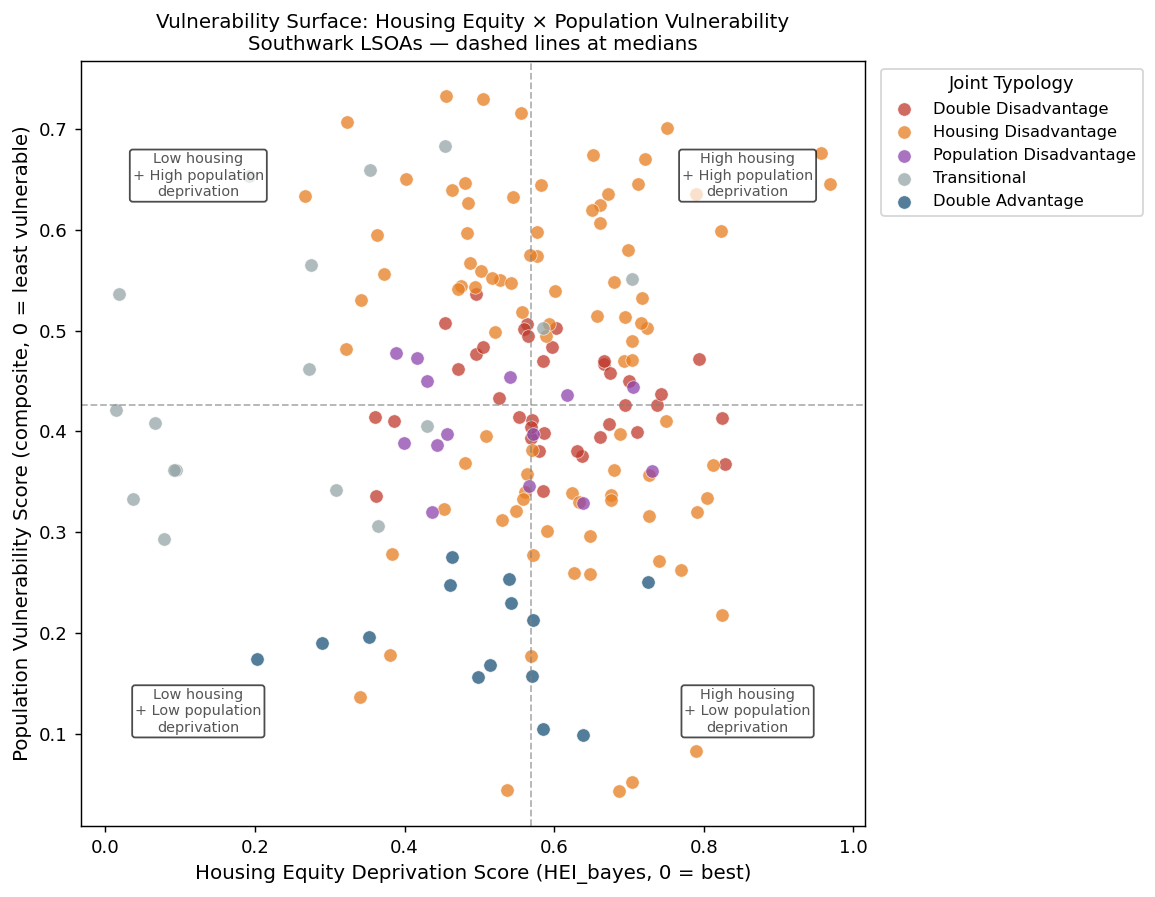

In [51]:
# ── 5.2  Scatter: housing deprivation × population vulnerability ──────────
fig, ax = plt.subplots(figsize=(9, 7))

for jt in JOINT_ORDER:
    sub = df[df['joint_type'] == jt]
    ax.scatter(sub['HEI_bayes'], sub['pop_vuln_score'],
               c=JOINT_COLORS[jt], label=jt, alpha=0.75, s=55, edgecolors='white', linewidths=0.4)

# Quadrant lines at medians
ax.axvline(df['HEI_bayes'].median(), color='grey', ls='--', lw=1, alpha=0.6)
ax.axhline(df['pop_vuln_score'].median(), color='grey', ls='--', lw=1, alpha=0.6)

# Quadrant labels
kw = dict(ha='center', va='center', fontsize=8, color='#555555',
          bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
ax.text(0.85, 0.85, 'High housing\n+ High population\ndeprivation', transform=ax.transAxes, **kw)
ax.text(0.15, 0.85, 'Low housing\n+ High population\ndeprivation', transform=ax.transAxes, **kw)
ax.text(0.85, 0.15, 'High housing\n+ Low population\ndeprivation', transform=ax.transAxes, **kw)
ax.text(0.15, 0.15, 'Low housing\n+ Low population\ndeprivation', transform=ax.transAxes, **kw)

ax.set_xlabel('Housing Equity Deprivation Score (HEI_bayes, 0 = best)', fontsize=11)
ax.set_ylabel('Population Vulnerability Score (composite, 0 = least vulnerable)', fontsize=11)
ax.set_title('Vulnerability Surface: Housing Equity × Population Vulnerability\n'
             'Southwark LSOAs — dashed lines at medians', fontsize=11)
ax.legend(title='Joint Typology', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_vulnerability_surface.png'), dpi=150, bbox_inches='tight')
plt.show()

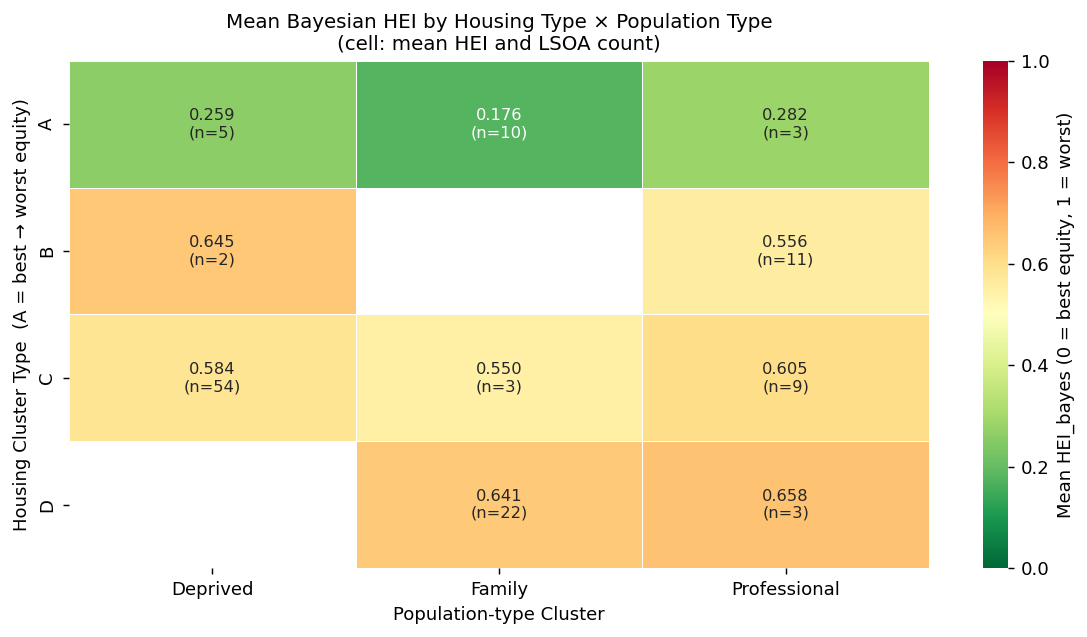

In [52]:
# ── 5.3  Mean HEI_bayes by housing type × population type (heatmap) ─────
pivot_hei = df.pivot_table(values='HEI_bayes', index='cluster_type',
                            columns='pop_label', aggfunc='mean')
pivot_hei = pivot_hei.reindex(index=HT_ORDER, columns=PT_ORDER)

pivot_n = df.pivot_table(values='HEI_bayes', index='cluster_type',
                          columns='pop_label', aggfunc='count')
pivot_n = pivot_n.reindex(index=HT_ORDER, columns=PT_ORDER)

# Build annotation: mean ± count
annot = pivot_hei.copy().astype(object)
for r in pivot_hei.index:
    for c in pivot_hei.columns:
        v = pivot_hei.loc[r,c]
        n = pivot_n.loc[r,c] if pd.notna(pivot_n.loc[r,c]) else 0
        annot.loc[r,c] = f'{v:.3f}\n(n={int(n)})' if pd.notna(v) else '—'

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_hei, annot=annot, fmt='', cmap='RdYlGn_r', center=0.5,
            vmin=0, vmax=1, ax=ax, linewidths=0.5, annot_kws={'fontsize':9},
            cbar_kws={'label':'Mean HEI_bayes (0 = best equity, 1 = worst)'})
ax.set_title('Mean Bayesian HEI by Housing Type × Population Type\n'
             '(cell: mean HEI and LSOA count)', fontsize=11)
ax.set_xlabel('Population-type Cluster')
ax.set_ylabel('Housing Cluster Type  (A = best → worst equity)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_hei_matrix_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Bivariate Spatial Analysis

In [53]:
# ── 6.1  Build spatial weights from shapefile ─────────────────────────────
import libpysal
from esda.moran import Moran_BV

geo_bv = gdf.merge(df[['lsoa21cd','HEI_bayes','pop_vuln_score',
                        'housing_score','pop_score','joint_score',
                        'pct_deprived_2plus','pct_poor_health',
                        'pct_elderly_alone','pct_dep_children']]                     .drop_duplicates('lsoa21cd'),
                   left_on=geo_col, right_on='lsoa21cd', how='left')

for col in ['HEI_bayes','pop_vuln_score','housing_score','pop_score',
            'pct_deprived_2plus','pct_poor_health']:
    geo_bv[col] = geo_bv[col].fillna(geo_bv[col].median())

w = libpysal.weights.Queen.from_dataframe(geo_bv, silence_warnings=True)
w.transform = 'r'
print(f'Spatial weights: {w.n} units, mean neighbours = {w.mean_neighbors:.2f}')

Spatial weights: 173 units, mean neighbours = 5.41


In [54]:
# ── 6.2  Bivariate Moran's I for key indicator pairs ─────────────────────
BV_PAIRS = [
    ('HEI_bayes',         'pop_vuln_score',     'HEI deprivation × Population vulnerability'),
    ('HEI_bayes',         'pct_deprived_2plus',  'HEI deprivation × Household deprivation (%)'),
    ('HEI_bayes',         'pct_poor_health',     'HEI deprivation × Poor health (%)'),
    ('HEI_bayes',         'pct_elderly_alone',   'HEI deprivation × Elderly alone (%)'),
    ('housing_score',     'pop_score',           'Housing equity score × Population vulnerability score'),
]

results = []
for x_var, y_var, label in BV_PAIRS:
    x = geo_bv[x_var].values
    y = geo_bv[y_var].values
    bv = Moran_BV(x, y, w, permutations=999)
    sig = '***' if bv.p_sim < 0.001 else ('**' if bv.p_sim < 0.01 else
          ('*' if bv.p_sim < 0.05 else 'ns'))
    results.append({'Indicator pair': label,
                    "Bivariate Moran's I": round(bv.I, 4),
                    'p-value': round(bv.p_sim, 4),
                    'Sig.': sig})
    print(f'{label}')
    print(f'  I = {bv.I:.4f}  |  p = {bv.p_sim:.4f}  {sig}')
    print()

bv_df = pd.DataFrame(results)
bv_df

HEI deprivation × Population vulnerability
  I = -0.0148  |  p = 0.4070  ns

HEI deprivation × Household deprivation (%)
  I = 0.0301  |  p = 0.2960  ns

HEI deprivation × Poor health (%)
  I = 0.0425  |  p = 0.2070  ns

HEI deprivation × Elderly alone (%)
  I = -0.0193  |  p = 0.3540  ns

Housing equity score × Population vulnerability score
  I = 0.0801  |  p = 0.0750  ns



,Indicator pair,Bivariate Moran's I,p-value,Sig.
0,HEI deprivation × Population vulnerability,-0.015,0.407,ns
1,HEI deprivation × Household deprivation (%),0.030,0.296,ns
2,HEI deprivation × Poor health (%),0.043,0.207,ns
3,HEI deprivation × Elderly alone (%),-0.019,0.354,ns
4,Housing equity score × Population vulnerabilit...,0.080,0.075,ns


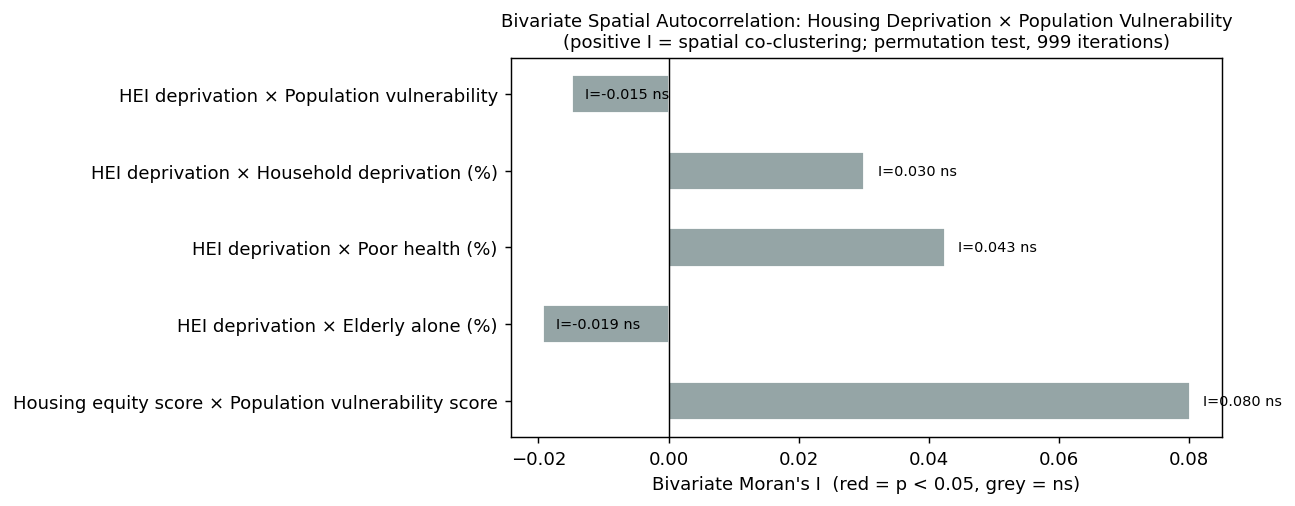

In [55]:
# ── 6.3  Bivariate Moran bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#c0392b' if r['p-value'] < 0.05 else '#95a5a6' for _, r in bv_df.iterrows()]
bars = ax.barh(bv_df['Indicator pair'], bv_df["Bivariate Moran's I"],
               color=colors, edgecolor='white', height=0.5)
ax.axvline(0, color='black', lw=0.8)
for bar, (_, row) in zip(bars, bv_df.iterrows()):
    moran_val = row["Bivariate Moran's I"]
    sig_val   = row['Sig.']
    label     = f"I={moran_val:.3f} {sig_val}"
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8)
ax.set_xlabel("Bivariate Moran's I  (red = p < 0.05, grey = ns)")
ax.set_title("Bivariate Spatial Autocorrelation: Housing Deprivation × Population Vulnerability\n"
             "(positive I = spatial co-clustering; permutation test, 999 iterations)",
             fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_bivariate_moran.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Policy Intervention Matrix

In [56]:
# ── 7.1  Policy matrix: housing type × population type ───────────────────
POLICY_MATRIX = {
    # (housing_type, pop_type): policy recommendation
    ('A','Deprived')     : 'Affordability support & social services',
    ('A','Elderly')      : 'Age-friendly services & community care',
    ('A','Family')       : 'Schools & childcare investment',
    ('A','Professional') : 'Maintain quality; market-led management',
    ('B','Deprived')     : 'Income support & tenure security',
    ('B','Elderly')      : 'Adaptation grants & healthcare access',
    ('B','Family')       : 'Green space & family facilities',
    ('B','Professional') : 'Preventive maintenance; sustainability',
    ('C','Deprived')     : 'Regeneration + social safety net',
    ('C','Elderly')      : 'EPC retrofit + mobility adaptations',
    ('C','Family')       : 'Housing quality improvement + play areas',
    ('C','Professional') : 'EPC upgrade incentives',
    ('D','Deprived')     : '⚑ PRIORITY: Comprehensive regeneration + wraparound support',
    ('D','Elderly')      : '⚑ PRIORITY: Retrofit + healthcare & mobility',
    ('D','Family')       : '⚑ PRIORITY: Overcrowding relief + child poverty programme',
    ('D','Professional') : 'Targeted retrofit; transport & EPC upgrade',
    ('E','Deprived')     : '⚑⚑ CRITICAL: Emergency regeneration + poverty intervention',
    ('E','Elderly')      : '⚑⚑ CRITICAL: Urgent retrofit + social care package',
    ('E','Family')       : '⚑⚑ CRITICAL: Rehousing programme + child welfare',
    ('E','Professional') : '⚑ PRIORITY: Structural retrofit + transport investment',
}

policy_df = pd.DataFrame(index=HT_ORDER, columns=PT_ORDER, dtype=str)
for (ht, pt), policy in POLICY_MATRIX.items():
    if ht in HT_ORDER and pt in PT_ORDER:
        policy_df.loc[ht, pt] = policy

# Fill any uncovered cells
policy_df = policy_df.fillna('Monitor & targeted support')

print('=== Policy Intervention Matrix ===')
policy_df

=== Policy Intervention Matrix ===


,Deprived,Family,Professional
A,Affordability support & social services,Schools & childcare investment,Maintain quality; market-led management
B,Income support & tenure security,Green space & family facilities,Preventive maintenance; sustainability
C,Regeneration + social safety net,Housing quality improvement + play areas,EPC upgrade incentives
D,⚑ PRIORITY: Comprehensive regeneration + wrapa...,⚑ PRIORITY: Overcrowding relief + child povert...,Targeted retrofit; transport & EPC upgrade


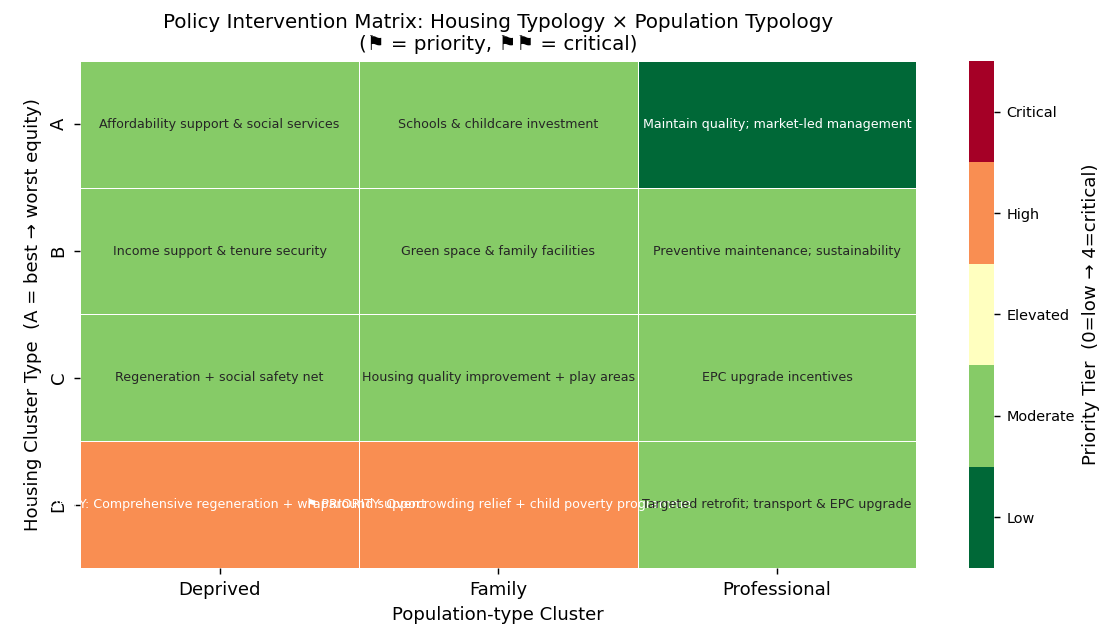

In [57]:
# ── 7.2  Priority tier heatmap ────────────────────────────────────────────
# Encode priority: 0=low, 1=moderate, 2=elevated, 3=high, 4=critical
def priority_score(policy):
    if '⚑⚑' in str(policy): return 4
    if '⚑'  in str(policy): return 3
    if 'PRIOR' in str(policy).upper(): return 2
    if 'Maintain' in str(policy) or 'market' in str(policy).lower(): return 0
    return 1

priority_mat = policy_df.map(priority_score)

fig, ax = plt.subplots(figsize=(9, 5))
cmap_p = plt.cm.get_cmap('RdYlGn_r', 5)
sns.heatmap(priority_mat, annot=policy_df, fmt='', cmap=cmap_p,
            vmin=0, vmax=4, ax=ax, linewidths=0.5,
            annot_kws={'fontsize': 7, 'wrap': True},
            cbar_kws={'label': 'Priority Tier  (0=low → 4=critical)',
                      'ticks': [0.4,1.2,2.0,2.8,3.6]})
ax.collections[0].colorbar.ax.set_yticklabels(
    ['Low','Moderate','Elevated','High','Critical'], fontsize=8)
ax.set_title('Policy Intervention Matrix: Housing Typology × Population Typology\n'
             '(⚑ = priority, ⚑⚑ = critical)', fontsize=11)
ax.set_xlabel('Population-type Cluster')
ax.set_ylabel('Housing Cluster Type  (A = best → worst equity)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_policy_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Composite Priority Scoring & Target LSOA Identification

In [58]:
# ── 8.1  Composite intervention priority score ────────────────────────────
# Components:
#   (1) HEI_bayes rank (housing deprivation, higher = worse)
#   (2) pop_vuln_score rank (population vulnerability, higher = worse)
#   (3) joint_score (ordinal combination, higher = worse)

df['rank_hei']      = df['HEI_bayes'].rank(ascending=True, pct=True)       # 1 = worst
df['rank_pop_vuln'] = df['pop_vuln_score'].rank(ascending=True, pct=True)  # 1 = worst

# Equal-weighted composite
df['priority_score'] = (df['rank_hei'] + df['rank_pop_vuln']) / 2

# Quintile-based priority tier
df['priority_tier'] = pd.qcut(df['priority_score'], q=5,
                               labels=['Tier 1 (lowest)','Tier 2','Tier 3',
                                       'Tier 4','Tier 5 (highest)'])

print('Priority tier distribution:')
print(df['priority_tier'].value_counts().sort_index())
print()
print('Mean HEI_bayes by tier:')
print(df.groupby('priority_tier')['HEI_bayes'].mean().round(3))

Priority tier distribution:
priority_tier
Tier 1 (lowest)     35
Tier 2              35
Tier 3              35
Tier 4              33
Tier 5 (highest)    35
Name: count, dtype: int64

Mean HEI_bayes by tier:
priority_tier
Tier 1 (lowest)    0.371
Tier 2             0.520
Tier 3             0.549
Tier 4             0.615
Tier 5 (highest)   0.710
Name: HEI_bayes, dtype: float64


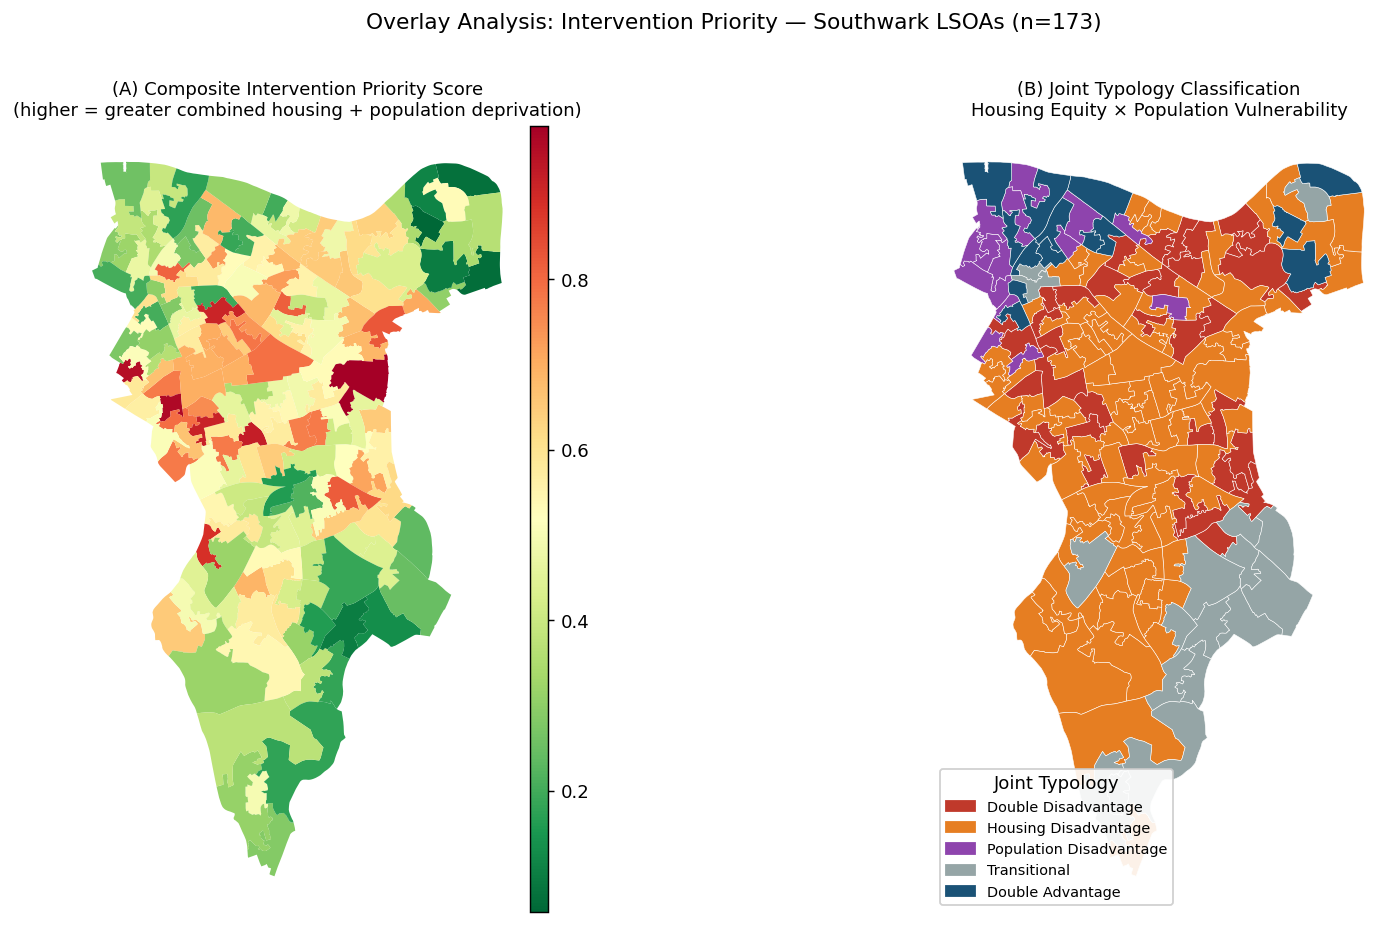

In [59]:
# ── 8.2  Priority score map ───────────────────────────────────────────────
geo_pri = gdf.merge(df[['lsoa21cd','priority_score','priority_tier',
                         'cluster_type','pop_label','joint_type']]                      .drop_duplicates('lsoa21cd'),
                    left_on=geo_col, right_on='lsoa21cd', how='left')
geo_pri['priority_score'] = geo_pri['priority_score'].fillna(geo_pri['priority_score'].median())

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel A: Continuous priority score
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='4%', pad=0.05)
geo_pri.plot(column='priority_score', cmap='RdYlGn_r', legend=True,
             ax=axes[0], cax=cax, missing_kwds={'color':'lightgrey'})
axes[0].set_title('(A) Composite Intervention Priority Score\n'
                  '(higher = greater combined housing + population deprivation)', fontsize=10)
axes[0].axis('off')

# Panel B: Joint typology overlay
for jt in JOINT_ORDER:
    sub = geo_pri[geo_pri['joint_type'] == jt]
    if not sub.empty:
        sub.plot(ax=axes[1], color=JOINT_COLORS[jt], edgecolor='white', linewidth=0.3)
geo_pri[geo_pri['joint_type'].isna()].plot(ax=axes[1], color='lightgrey',
                                            edgecolor='white', linewidth=0.3)
jt_handles = [mpatches.Patch(color=JOINT_COLORS[jt], label=jt) for jt in JOINT_ORDER]
axes[1].legend(handles=jt_handles, title='Joint Typology', fontsize=8,
               loc='lower left', framealpha=0.9)
axes[1].set_title('(B) Joint Typology Classification\n'
                  'Housing Equity × Population Vulnerability', fontsize=10)
axes[1].axis('off')

plt.suptitle('Overlay Analysis: Intervention Priority — Southwark LSOAs (n=173)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overlay_priority_map.png'), dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# ── 8.3  Top-20 priority LSOAs ────────────────────────────────────────────
top20 = (df.sort_values('priority_score', ascending=False)
           .head(20)[['lsoa21cd','lsoa21nm','cluster_type','pop_label',
                       'joint_type','HEI_bayes','pop_vuln_score','priority_score']]
           .reset_index(drop=True))
top20.index += 1

# Lookup policy for each
top20['recommended_intervention'] = top20.apply(
    lambda r: POLICY_MATRIX.get((r['cluster_type'], r['pop_label']),
                                 'Monitor & targeted support'), axis=1)

print('=== Top 20 Priority LSOAs for Intervention ===')
top20[['lsoa21nm','cluster_type','pop_label','HEI_bayes',
       'pop_vuln_score','priority_score','recommended_intervention']]

=== Top 20 Priority LSOAs for Intervention ===


,lsoa21nm,cluster_type,pop_label,HEI_bayes,pop_vuln_score,priority_score,recommended_intervention
1,Southwark 018B,C,Deprived,0.956,0.676,0.980,Regeneration + social safety net
2,Southwark 021E,C,Deprived,0.968,0.645,0.960,Regeneration + social safety net
3,Southwark 014A,C,Deprived,0.751,0.700,0.951,Regeneration + social safety net
4,Southwark 019A,C,Deprived,0.789,0.636,0.919,Regeneration + social safety net
5,Southwark 020D,C,Deprived,0.823,0.598,0.913,Regeneration + social safety net
6,Southwark 012B,C,Deprived,0.722,0.670,0.910,Regeneration + social safety net
7,Southwark 027B,C,Deprived,0.713,0.645,0.887,Regeneration + social safety net
8,Southwark 011A,C,Deprived,0.652,0.673,0.827,Regeneration + social safety net
9,Southwark 026E,C,Deprived,0.698,0.580,0.818,Regeneration + social safety net
10,Southwark 013E,C,Deprived,0.672,0.635,0.815,Regeneration + social safety net


In [61]:
# ── 8.4  Summary statistics by joint typology ─────────────────────────────
summary = df.groupby('joint_type').agg(
    n_LSOAs        = ('lsoa21cd','count'),
    mean_HEI       = ('HEI_bayes','mean'),
    mean_pop_vuln  = ('pop_vuln_score','mean'),
    mean_priority  = ('priority_score','mean'),
    pct_deprived   = ('pct_deprived_2plus','mean'),
    pct_poor_health= ('pct_poor_health','mean'),
).reindex(JOINT_ORDER).dropna(how='all').round(3)

print('=== Summary Statistics by Joint Typology ===')
summary

=== Summary Statistics by Joint Typology ===


,n_LSOAs,mean_HEI,mean_pop_vuln,mean_priority,pct_deprived,pct_poor_health
joint_type,,,,,,
Double Disadvantage,37,0.600,0.435,0.541,0.209,0.045
Housing Disadvantage,91,0.601,0.463,0.571,0.203,0.041
Population Disadvantage,14,0.524,0.404,0.419,0.203,0.046
Transitional,17,0.255,0.462,0.348,0.193,0.043
Double Advantage,14,0.497,0.194,0.232,0.099,0.023


---
## 9. Save Outputs

In [62]:
# Save overlay dataset
out_cols = ['lsoa21cd','lsoa21nm','cluster_type','pop_label','joint_type',
            'housing_score','pop_score','joint_score',
            'pop_vuln_score','priority_score','priority_tier',
            'HEI_bayes','HEI_adjusted'] + POP_VARS + HEI_FEAT_COLS
out_df = df[[c for c in out_cols if c in df.columns]].copy()
out_df.to_csv(os.path.join(DATA, 'southwark_rq6_overlay.csv'), index=False)
print('Saved → southwark_rq6_overlay.csv')

# Save top priority LSOAs
top20.to_csv(os.path.join(DATA, 'southwark_priority_lsoas.csv'), index=False)
print('Saved → southwark_priority_lsoas.csv')

print()
print('=== RQ6 Overlay Analysis Complete ===')
print(f'  {len(df)} LSOAs analysed')
print(f'  {len(HT_ORDER)} housing types × {len(PT_ORDER)} population types')
print(f'  {len(df["joint_type"].unique())} joint typology categories')
print(f'  Figures saved to: {FIG_DIR}')

Saved → southwark_rq6_overlay.csv
Saved → southwark_priority_lsoas.csv

=== RQ6 Overlay Analysis Complete ===
  173 LSOAs analysed
  4 housing types × 3 population types
  5 joint typology categories
  Figures saved to: /Users/kevin/Desktop/代写/lxy/code/figures
